# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

Cargar el DataFrame.

In [7]:
df_ejercicios = spark.read.parquet("resultados/")

Muestra el esquema completo.

In [8]:
df_ejercicios.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)



Indica cuantas filas contine.

In [9]:
df_ejercicios.count()

194

¿Cuántos sensores distintos (sensor_id) aparecen?

In [10]:
df_ejercicios.select("sensor_id").distinct().count()

4

### Ejercicio 2

Crea una columna basada en la diferencia o relación entre dos métricas numéricas del DataFrame.

In [11]:
df_ej2 = df_ejercicios.select(
    (col("avg_temp")/col("avg_humidity")).alias("th")
)

df_ej2.show(2)

+------------------+
|                th|
+------------------+
| 0.799254301804964|
|0.8341206536048944|
+------------------+
only showing top 2 rows



¿Cuál es el valor mínimo, máximo y medio de la nueva columna?

In [12]:
estadisticos_ej2 = df_ej2.agg(
    avg("th").alias("Media"),
    max("th").alias("Máximo"),
    min("th").alias("Mínimo")
)

estadisticos_ej2.show()

+------------------+-----------------+-----------------+
|             Media|           Máximo|           Mínimo|
+------------------+-----------------+-----------------+
|1.0470850582926459|3.816812439261419|0.526397330473126|
+------------------+-----------------+-----------------+



### Ejercicio 3

Aplica un filtro usando varias condiciones a la vez relacionadas con:
- Humedad (avg_humidity)
- Número de eventos (num_events)
- Sensor (sensor_id)

In [13]:
df_ej3 = df_ejercicios.filter(
    col("avg_humidity") > 50
).filter(
    col("num_events") > 5
).filter(
    col("sensor_id") != "S1"
)

df_ej3.show(2)

+--------------------+---------+------------------+-----------------+-----------------+----------+
|              window|sensor_id|         avg_value|         avg_temp|     avg_humidity|num_events|
+--------------------+---------+------------------+-----------------+-----------------+----------+
|{2025-12-14 14:57...|       S4| 30.67428571428572|47.21142857142858|60.66571428571428|         7|
|{2025-12-14 14:58...|       S3|30.156666666666666|            58.75|64.12666666666667|         6|
+--------------------+---------+------------------+-----------------+-----------------+----------+
only showing top 2 rows



¿Cuántos registros cumplen todas las condiciones aplicadas?

In [14]:
df_ej3.count()

73

### Ejercicio 4

Agrupa el DataFrame por sensor_id y obtén estadísticas descriptivas.

In [15]:
df_ej4 = df_ejercicios.groupBy(df_ejercicios.sensor_id)

¿Qué sensor tiene la mayor media en la variable analizada? (Se analizará tanto la humedad como la temperatura)

In [16]:
df_ej4_1 = df_ej4.agg(
    avg("avg_temp").alias("Media temperatura"),
    avg("avg_humidity").alias("Media humedad")
)

df_ej4_1.show()

+---------+-----------------+------------------+
|sensor_id|Media temperatura|     Media humedad|
+---------+-----------------+------------------+
|       S4|54.58995767950871|53.144521782072786|
|       S3|54.68323151907195| 53.12715334665334|
|       S2|51.56177571634714| 55.22394296463174|
|       S1|55.51667871074503|53.140863527628845|
+---------+-----------------+------------------+



En cuanto a la temperatura, el sensor que más media tiene de dicha variable es el sensor 1. Mientras que en cuanto a la humedad, el sensor que más tiene de la misma es el sensor 2.

¿Qué sensor presenta la temperatura máxima?

In [17]:
df_ej4_2 = df_ej4.agg(
    max("avg_temp").alias("Máxima temperatura")
)

df_ej4_2.show()

+---------+------------------+
|sensor_id|Máxima temperatura|
+---------+------------------+
|       S4|            85.405|
|       S3| 69.85999999999999|
|       S2| 62.84454545454546|
|       S1|             88.55|
+---------+------------------+



El sensor cuya temperatura máxima es superior a los demás es el sensor 1.

¿Cuántos grupos o ventanas existen por sensor?

In [18]:
df_ej4_3 = df_ej4.agg(
    count("window").alias("Ventanas o grupos")
)

df_ej4_3.show()

+---------+-----------------+
|sensor_id|Ventanas o grupos|
+---------+-----------------+
|       S4|               49|
|       S3|               47|
|       S2|               49|
|       S1|               49|
+---------+-----------------+



### Ejercicio 5

Usa funciones de ventana para identificar, para cada sensor, el registro con el mayor valor de avg_value.

In [19]:
ventana_por_sensor = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

df_ej5 = df_ejercicios.withColumn(
    "rank_value", row_number().over(ventana_por_sensor)
).filter(
    col("rank_value") == 1
)

df_ej5.show()

+--------------------+---------+-----------------+-----------------+------------------+----------+----------+
|              window|sensor_id|        avg_value|         avg_temp|      avg_humidity|num_events|rank_value|
+--------------------+---------+-----------------+-----------------+------------------+----------+----------+
|{2025-12-14 15:02...|       S1|           39.008|           58.926|56.970000000000006|         5|         1|
|{2025-12-14 15:14...|       S2|           39.912|44.76800000000001|            53.624|         5|         1|
|{2025-12-14 15:19...|       S3|38.82727272727272|58.46272727272728|51.408181818181816|        11|         1|
|{2025-12-14 15:07...|       S4|          39.4225|          43.6475|           50.5025|         4|         1|
+--------------------+---------+-----------------+-----------------+------------------+----------+----------+



¿Qué sensor obtiene el valor máximo global entre todos?

El sensor que obtiene un mayor valor de avg_value es el sensor 2.

### Ejercicio 6

Crea un DataFrame auxiliar con información adicional sobre sensores (por ejemplo, categoría, ubicación o tipo) y realiza un join.

In [20]:
rdd_inf_ad = spark.sparkContext.parallelize([
    ("S1", "categoria1", "ubicacion1", "tipo1"),
    ("S2", "categoria2", "ubicacion2", "tipo2"),
    ("S3", "categoria3", "ubicacion3", "tipo3"),
    ("S4", "categoria4", "ubicacion4", "tipo4")
])

df_inf_ad = spark.createDataFrame(rdd_inf_ad)

df_inf_ad.printSchema()

root
 |-- _1: string (nullable = true)
 |-- _2: string (nullable = true)
 |-- _3: string (nullable = true)
 |-- _4: string (nullable = true)



In [21]:
df_inf_ad = df_inf_ad.withColumnRenamed(
    "_1", "sensor_id"
).withColumnRenamed(
    "_2", "categoria"
).withColumnRenamed(
    "_3", "ubicacion"
).withColumnRenamed(
    "_4", "tipo"
)

df_inf_ad.printSchema()

root
 |-- sensor_id: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- ubicacion: string (nullable = true)
 |-- tipo: string (nullable = true)



In [22]:
df_ej6 = df_ejercicios.join(df_inf_ad, df_ejercicios.sensor_id == df_inf_ad.sensor_id, "inner")

df_ej6.show(2)

+--------------------+---------+-----------------+------------------+-----------------+----------+---------+----------+----------+-----+
|              window|sensor_id|        avg_value|          avg_temp|     avg_humidity|num_events|sensor_id| categoria| ubicacion| tipo|
+--------------------+---------+-----------------+------------------+-----------------+----------+---------+----------+----------+-----+
|{2025-12-14 15:31...|       S1|           27.425|49.120000000000005|            54.29|         2|       S1|categoria1|ubicacion1|tipo1|
|{2025-12-14 15:18...|       S1|38.68666666666667|45.038333333333334|52.13333333333333|         6|       S1|categoria1|ubicacion1|tipo1|
+--------------------+---------+-----------------+------------------+-----------------+----------+---------+----------+----------+-----+
only showing top 2 rows



Muestra los cinco primeros registros del DataFrame ya unido.

In [23]:
print("Muestra de los 5 primeros registros del DF unido")

df_ej6.show(5)

Muestra de los 5 primeros registros del DF unido
+--------------------+---------+------------------+------------------+-----------------+----------+---------+----------+----------+-----+
|              window|sensor_id|         avg_value|          avg_temp|     avg_humidity|num_events|sensor_id| categoria| ubicacion| tipo|
+--------------------+---------+------------------+------------------+-----------------+----------+---------+----------+----------+-----+
|{2025-12-14 15:31...|       S1|            27.425|49.120000000000005|            54.29|         2|       S1|categoria1|ubicacion1|tipo1|
|{2025-12-14 15:18...|       S1| 38.68666666666667|45.038333333333334|52.13333333333333|         6|       S1|categoria1|ubicacion1|tipo1|
|{2025-12-14 15:11...|       S1|            34.805|             44.17|            83.91|         2|       S1|categoria1|ubicacion1|tipo1|
|{2025-12-14 15:20...|       S1|27.022727272727273| 59.87909090909091|64.13818181818182|        11|       S1|categoria1|ubi

### Ejercicio 7

Extrae la marca de inicio de la ventana y agrúpala por unidades de tiempo truncadas (p. ej., minuto u hora).

In [24]:
df_ej7 = df_ejercicios.withColumn("tiempo_truncado", date_trunc("minute", col("window.start")))

df_ej7.show(2)

+--------------------+---------+-----------------+------------------+-----------------+----------+-------------------+
|              window|sensor_id|        avg_value|          avg_temp|     avg_humidity|num_events|    tiempo_truncado|
+--------------------+---------+-----------------+------------------+-----------------+----------+-------------------+
|{2025-12-14 15:19...|       S1|21.45181818181818| 46.57545454545455|58.27363636363636|        11|2025-12-14 15:19:00|
|{2025-12-14 15:19...|       S2|            35.83|53.855000000000004|           64.565|         2|2025-12-14 15:19:00|
+--------------------+---------+-----------------+------------------+-----------------+----------+-------------------+
only showing top 2 rows



¿Cuántas ventanas hay por unidad temporal?

In [25]:
df_ej7_1 = df_ej7.groupBy("tiempo_truncado").agg(
    count("window").alias("Ventanas")
)

df_ej7_1.show()

+-------------------+--------+
|    tiempo_truncado|Ventanas|
+-------------------+--------+
|2025-12-14 14:58:00|       8|
|2025-12-14 14:57:00|       8|
|2025-12-14 15:19:00|       8|
|2025-12-14 14:59:00|       8|
|2025-12-14 15:02:00|       8|
|2025-12-14 15:01:00|       8|
|2025-12-14 15:00:00|       8|
|2025-12-14 15:07:00|       8|
|2025-12-14 15:04:00|       8|
|2025-12-14 15:03:00|       8|
|2025-12-14 15:05:00|       8|
|2025-12-14 15:10:00|       8|
|2025-12-14 15:08:00|       8|
|2025-12-14 15:09:00|       8|
|2025-12-14 15:11:00|       8|
|2025-12-14 15:15:00|       8|
|2025-12-14 15:13:00|       8|
|2025-12-14 15:16:00|       8|
|2025-12-14 15:12:00|       3|
|2025-12-14 14:56:00|       3|
+-------------------+--------+
only showing top 20 rows



¿Cuál es la humedad media por cada unidad?

In [26]:
df_ej7_2 = df_ej7.groupBy("tiempo_truncado").agg(
    avg("avg_humidity").alias("Media humedad")
)

df_ej7_2.show()

+-------------------+------------------+
|    tiempo_truncado|     Media humedad|
+-------------------+------------------+
|2025-12-14 14:58:00| 57.52567866161616|
|2025-12-14 14:57:00| 53.49990584415585|
|2025-12-14 15:19:00| 56.44747727272727|
|2025-12-14 14:59:00|   49.895680746337|
|2025-12-14 15:02:00|55.411894345238096|
|2025-12-14 15:01:00| 55.92086111111111|
|2025-12-14 15:00:00| 53.27360367063493|
|2025-12-14 15:07:00| 53.32198695054945|
|2025-12-14 15:04:00|57.966261904761915|
|2025-12-14 15:03:00| 53.86722916666666|
|2025-12-14 15:05:00|50.240146464646465|
|2025-12-14 15:10:00| 47.84158432539682|
|2025-12-14 15:08:00| 52.47910763888889|
|2025-12-14 15:09:00|51.567258071789325|
|2025-12-14 15:11:00| 55.05451772186147|
|2025-12-14 15:15:00|52.976288194444436|
|2025-12-14 15:13:00|55.606044871794865|
|2025-12-14 15:16:00| 54.83677938034188|
|2025-12-14 15:12:00|59.020999999999994|
|2025-12-14 14:56:00|37.705555555555556|
+-------------------+------------------+
only showing top

### Ejercicio 8

Reparte el DataFrame por sensor_id y añade una columna indicando el identificador de partición.

In [27]:
df_ej8_reparticionado = df_ejercicios.repartition(4, "sensor_id")

df_ej8 = df_ej8_reparticionado.withColumn("id_particion", spark_partition_id())

¿Cuál es la distribución de registros entre las particiciones?

In [28]:
df_ej8_1 = df_ej8.groupBy("id_particion").agg(
    count("sensor_id").alias("Registros")
)

df_ej8_1.show()

+------------+---------+
|id_particion|Registros|
+------------+---------+
|           0|       47|
|           1|       98|
|           3|       49|
+------------+---------+



### Ejercicio 9

Define un criterio personalizado de "anomalía" basado en los valores medios del DataFrame.

Para establecer un criterio de anomalia sobre la variable avg_value, se empleará el siguiente cálculo:

$$
|x - \mu| > 2 \cdot \sigma
$$

Esto significa que un valor será anómalo cuando este sea menor que la media más dos veces la desviación típica, o cuando el valor sea mayor a la media menos dos veces la desviación típica. 

In [29]:
media = df_ejercicios.agg(
    avg("avg_value")
).first()[0]

print(f"Media: {media}")

desviacion = df_ejercicios.agg(
    stddev("avg_value")
).first()[0]

print(f"Desviación típica: {desviacion}")

Media: 29.530474792818865
Desviación típica: 5.07097660183446


In [30]:
df_ej9 = df_ejercicios.withColumn(
    "anomalia", abs(col("avg_value") - media) > (2 * desviacion)
)

df_ej9.show(2)

+--------------------+---------+-----------------+------------------+-----------------+----------+--------+
|              window|sensor_id|        avg_value|          avg_temp|     avg_humidity|num_events|anomalia|
+--------------------+---------+-----------------+------------------+-----------------+----------+--------+
|{2025-12-14 15:19...|       S1|21.45181818181818| 46.57545454545455|58.27363636363636|        11|   false|
|{2025-12-14 15:19...|       S2|            35.83|53.855000000000004|           64.565|         2|   false|
+--------------------+---------+-----------------+------------------+-----------------+----------+--------+
only showing top 2 rows



¿Cuántos registros son anómalos?

In [31]:
df_ej9.filter(
    col("anomalia") == "true"
).count()

9

¿Qué sensor tiene más anomalías?

In [32]:
df_ej9_1 = df_ej9.filter(
    col("anomalia") == "true"
).groupBy("sensor_id").agg(
    count("anomalia").alias("Nº anomalías")
)

df_ej9_1.show()

+---------+------------+
|sensor_id|Nº anomalías|
+---------+------------+
|       S3|           1|
|       S2|           6|
|       S1|           1|
|       S4|           1|
+---------+------------+



El sensor con mayor número de anomalías es el sensor 2.

### Ejercicio 10

Crea una puntuación combinando varias columnas del DataFrame (por ejemplo, ponderando avg_value, temperatura y humedad).

In [33]:
df_ej10 = df_ejercicios.withColumn(
    "puntuacion", (col("avg_value") * (1/3)) + (col("avg_temp") * (1/3)) + (col("avg_humidity") * (1/3))
).orderBy(col("puntuacion").desc())

¿Qué sensor obtiene la puntuación más alta? 
¿Cuál es el valor de dicha puntuación?

In [34]:
df_ej10.show(1)

+--------------------+---------+---------+--------+------------+----------+------------------+
|              window|sensor_id|avg_value|avg_temp|avg_humidity|num_events|        puntuacion|
+--------------------+---------+---------+--------+------------+----------+------------------+
|{2025-12-14 15:12...|       S1|     30.0|   88.55|        60.0|         1|59.516666666666666|
+--------------------+---------+---------+--------+------------+----------+------------------+
only showing top 1 row



El sensor que obtiene la puntuación más alta es el sensor 1 con una puntuación de 59.5167

### Ejercicio 11

Crea dos gráficos, convirtiendo el DF de spark a pandas y utiliza la libreria matplotlib para generar dos gráficos sobre alguna de las variables.

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

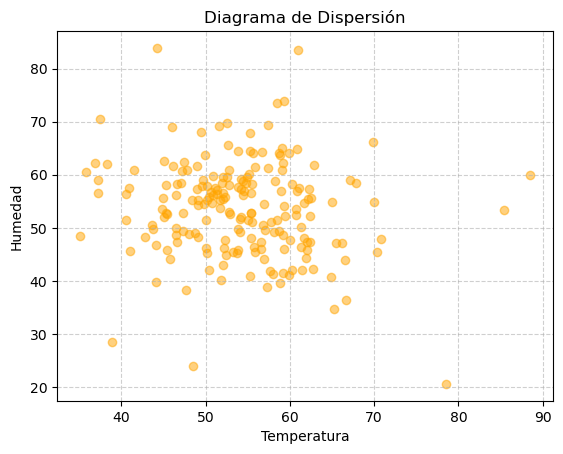

In [38]:
df_ej11 = df_ejercicios.select(
    col("avg_temp"), col("avg_humidity")
)

df_ej11_pandas = df_ej11.toPandas()

plt.scatter(df_ej11_pandas["avg_temp"], df_ej11_pandas["avg_humidity"], alpha=0.5, color="orange")
plt.title("Diagrama de Dispersión")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

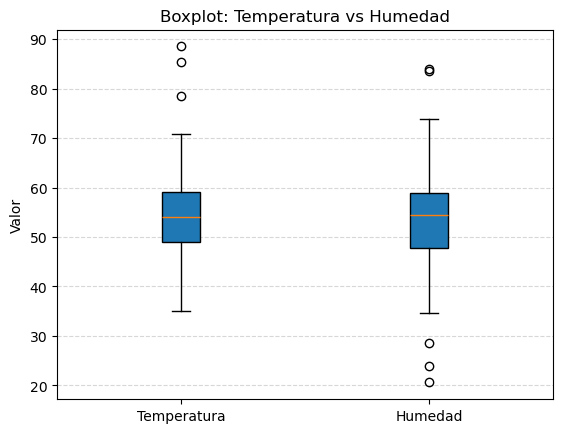

In [39]:
plt.boxplot(df_ej11_pandas, labels=['Temperatura', 'Humedad'], patch_artist=True)
plt.title("Boxplot: Temperatura vs Humedad")
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()